# Cobertura vacinal por município

**Pergunta que este notebook responde:** quantas doses de cada vacina foram
aplicadas e qual a cobertura alcançada nos municípios do estado?

**Fonte:** PNI — Programa Nacional de Imunizações.
**Tempo estimado:** 3 a 5 minutos.

> O PNI é a única base que já traz **a cobertura calculada** (coluna `COBERT`),
> além das doses aplicadas e da população-alvo.

## Preparação

In [2]:
%pip install pysus==2.10.6 nest_asyncio -q
import nest_asyncio
nest_asyncio.apply()
print("Ambiente pronto.")

Note: you may need to restart the kernel to use updated packages.
Ambiente pronto.


## Parâmetros

In [3]:
UF = "PR"
ANO = 2019    # o PNI no catálogo tem defasagem maior que as outras bases

## Passo 1 — Ver quais anos existem

In [4]:
from pysus import list_files

catalogo = list_files(dataset="pni", state=UF)
anos = sorted({int(a) for a in catalogo["year"].dropna()})

print(f"Anos disponíveis para {UF}: {anos[-12:]}")
print(f"{ANO} disponível? {'sim' if ANO in anos else 'NÃO — escolha um acima'}")

Anos disponíveis para PR: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2025, 2026]
2019 disponível? sim


## Passo 2 — Baixar os dados de vacinação

In [5]:
from pysus import pni

vacinacao = pni(state=UF, year=ANO, as_dataframe=True)

print(f"{len(vacinacao):,} registros de {UF}, {ANO}")
print("Colunas:", list(vacinacao.columns))

225,717 registros de PR, 2019
Colunas: ['ANO', 'UF', 'MUNIC', 'IMUNO', 'QT_DOSE', 'POP', 'COBERT', 'ANOMES', 'MES', 'FX_ETARIA', 'DOSE', 'DOSE1', 'DOSEN', 'DIFER']


Cada linha combina um **município**, um **imunobiológico** (a vacina) e uma
**faixa etária**, com:

| Coluna | Significado |
|---|---|
| `MUNIC` | Código IBGE do município |
| `IMUNO` | Código do imunobiológico (a vacina) |
| `QT_DOSE` | Doses aplicadas |
| `POP` | População-alvo |
| `COBERT` | Cobertura vacinal calculada (%) |
| `FX_ETARIA` | Faixa etária |

## Passo 3 — Doses aplicadas por vacina

In [6]:
import pandas as pd

vacinacao["QT_DOSE"] = pd.to_numeric(vacinacao["QT_DOSE"], errors="coerce").fillna(0)

por_vacina = (
    vacinacao.groupby("IMUNO")["QT_DOSE"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .rename_axis("Código da vacina")
    .reset_index(name="Doses aplicadas")
)
por_vacina

,Código da vacina,Doses aplicadas
0,06,742886
1,04,266858
2,53,207528
3,103,188562
4,52,168317
5,21,160437
6,12,145668
7,49,142602
8,08,129063
9,61,92725


> Os códigos de imunobiológico são definidos pelo Ministério da Saúde. Alguns
> dos mais comuns: `020` BCG, `035` Hepatite B, `047` Pentavalente,
> `061` Tríplice viral, `066` Febre amarela, `085` HPV.

## Passo 4 — Cobertura vacinal por município

A coluna `COBERT` já vem calculada pelo próprio PNI (doses ÷ população-alvo).

In [7]:
vacinacao["COBERT"] = pd.to_numeric(vacinacao["COBERT"], errors="coerce")

cobertura = (
    vacinacao.dropna(subset=["COBERT"])
    .groupby("MUNIC")["COBERT"]
    .mean()
    .sort_values(ascending=False)
)

print(f"Municípios com cobertura registrada: {len(cobertura):,}")
print(f"Cobertura média no estado: {cobertura.mean():.1f}%")
print()
print("Cinco maiores coberturas médias:")
print(cobertura.head().round(1).to_string())

Municípios com cobertura registrada: 399
Cobertura média no estado: 5.8%
Cinco maiores coberturas médias:
MUNIC
410855    75.0
410340    59.1
410657    50.0
410347    45.6
410275    41.7


## Passo 5 — Doses ao longo do ano

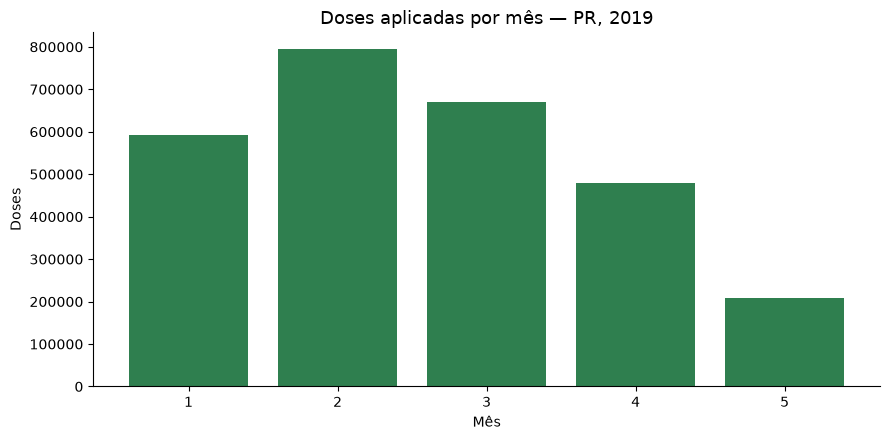

In [8]:
import matplotlib.pyplot as plt

if "MES" in vacinacao.columns:
    por_mes = (
        vacinacao.assign(MES=pd.to_numeric(vacinacao["MES"], errors="coerce"))
        .dropna(subset=["MES"])
        .groupby("MES")["QT_DOSE"].sum()
        .sort_index()
    )

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.bar(por_mes.index.astype(int).astype(str), por_mes.values, color="#2f7f4f")
    ax.set_title(f"Doses aplicadas por mês — {UF}, {ANO}", fontsize=13)
    ax.set_xlabel("Mês")
    ax.set_ylabel("Doses")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()
else:
    print("Coluna MES não disponível neste ano.")

## Como interpretar

- Coberturas acima de 100% são comuns e **não são erro**: acontecem quando a
  população-alvo estimada é menor que a real, ou quando pessoas de municípios
  vizinhos se vacinam ali.
- Metas do Ministério da Saúde giram em torno de 90% a 95%, conforme a vacina.
- Coberturas muito baixas em municípios pequenos podem refletir problemas de
  registro, não necessariamente de vacinação.

## Como adaptar

- **Outro estado ou ano:** mude `UF` e `ANO`.
- **Uma vacina específica:** filtre `IMUNO` pelo código de interesse.
- **Por faixa etária:** agrupe por `FX_ETARIA`.

## Verificação de sanidade

Toda análise deste repositório termina conferindo o próprio resultado. Não é
formalidade: uma mudança no catálogo do DATASUS já fez notebooks devolverem o
Brasil inteiro rotulado como um estado, **sem erro nenhum**. Falhar alto é
incômodo; acertar o formato e errar o número vira decisão errada.

In [9]:
print("Verificações\n")
falhas = []


def conferir(numero, descricao, condicao, detalhe=""):
    marca = "confere" if condicao else "ATENÇÃO"
    print(f"{numero}. {descricao}{(' — ' + detalhe) if detalhe else ''}: {marca}")
    if not condicao:
        falhas.append(descricao)

def soma(x):
    """Soma numérica de escalar, Series ou DataFrame. Sempre devolve número."""
    import numpy as np
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    if isinstance(x, pd.DataFrame):
        return float(x.select_dtypes("number").to_numpy().sum())
    return float(pd.to_numeric(pd.Series(x), errors="coerce").sum())


def quantos(x):
    """Quantidade de itens, aceitando também um número já contado."""
    import numpy as np
    if isinstance(x, (int, float, np.integer, np.floating)):
        return int(x)
    return len(x)


conferir(1, "Vieram registros de vacinação", len(vacinacao) > 0,
         f"{len(vacinacao):,} registros")
conferir(2, "Há mais de uma vacina no recorte", len(por_vacina) > 1,
         f"{len(por_vacina)} vacinas")
# No PNI a linha NAO e uma dose: ha coluna de quantidade. Somar doses e
# comparar com o numero de linhas era o erro que este repositorio inteiro
# ensina a nao cometer — e eu o cometi na propria conferencia.
conferir(3, "Há mais doses aplicadas do que linhas (a linha não é a dose)",
         soma(por_vacina) >= len(vacinacao),
         f"{soma(por_vacina):,.0f} doses em {len(vacinacao):,} linhas")
# Cobertura e percentual: acima de 200% quase sempre e denominador errado
if "cobertura" in dir() and hasattr(cobertura, "max"):
    try:
        pico = float(pd.to_numeric(cobertura, errors="coerce").max())
        conferir(4, "Nenhuma cobertura absurda (acima de 200%)",
                 pico <= 200, f"máximo {pico:.0f}%")
    except Exception:
        pass

print()
if falhas:
    print("ATENÇÃO: revise antes de usar estes números —", falhas)
else:
    print("Tudo confere.")

Verificações
1. Vieram registros de vacinação — 225,717 registros: confere
2. Há mais de uma vacina no recorte — 15 vacinas: confere
3. Há mais doses aplicadas do que linhas (a linha não é a dose) — 2,578,390 doses em 225,717 linhas: confere
4. Nenhuma cobertura absurda (acima de 200%) — máximo 75%: confere
Tudo confere.


---
*Notebook do projeto [PySusNoCode](https://github.com/cartaproale/PySusNoCode) —
um produto [Kraemer Academy](https://kraemeracademy.net).
Validado com dados reais do DATASUS.*